# Code: ARIMA

*Prepared by Michael Lawrence Castanares, PhD*

`To begin is for everyone. To persevere is for saints - St. Josemaria Escriva`

Note: Most of the contents are taken from my MSDS Time Series class taught by Prof. Sebastian Ibanez, PhD

In [1]:
%%capture
!pip install statsforecast

In [2]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
)

In [3]:
# Helper functions
def apply_chart_template(filename=None):
    """
    Decorator to apply minimal plot styling by removing spines and the y-axis.
    """
    def decorator(func):
        def wrapper(*args, **kwargs):
            result = func(*args, **kwargs)
            for spine in ['top', 'right']:
                plt.gca().spines[spine].set_visible(False)
            #set font size
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            #remove x-labels
            plt.xlabel('')  # Remove x-axis title
            #plt.gca().axes.get_yaxis().set_visible(False)
            plt.tight_layout()
            if filename:
                plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            return result
        return wrapper
    return decorator

We setup the series into a standard format accepted by Nixtla packages. The table should be in long-format with columns: 

* date (`ds`),
* variable name (`unique_id`), and 
* value (`y`).

We will also fillin missing values using the recent past values (forward-fill method)

In [39]:
####Load the three datasets
def proc_fillin_missingdates(df_in: pd.DataFrame,
                             unique_id: str,
                             freq: str) -> pd.DataFrame:
    """
    Process the input DataFrame to fill in missing dates and values.
    """
    #fillin missing values from recent past value (ffill)
    df = pd.DataFrame({'ds': pd.date_range(start=df_in['date'].min(),
                                            end=df_in['date'].max(),
                                            freq=freq)})    
    df['unique_id'] = unique_id
    df['y'] = df_in.set_index('date').reindex(df['ds'])['y'].values
    df.fillna(method='ffill', inplace=True)

    return df

####AUD/PHP exchange rate
SELECT_COL = ['Series ID','FXRPHP']
loc_TRAIN = pd.to_datetime('2026-02-01')

df_aud = pd.read_excel('2023-current.xls',
                       sheet_name='Data',
                       skiprows=10)
df_aud = df_aud[SELECT_COL]
df_aud = df_aud.rename(columns={
    'Series ID':'date',
    'FXRPHP':'y'})
df_aud = proc_fillin_missingdates(df_aud, 'AUDPHP', 'D')

print('Series: AUD/PHP Exchange rate')
display(df_aud.head())

##### AU Inflation rate
# Quarterly weighted median inflation  – excluding interest charges and tax changes
SELECT_COL = ['Series ID','GCPIOCPMWMQP']
df_inf = pd.read_excel('g01hist.xlsx',
                    skiprows=10)[SELECT_COL]
df_inf = df_inf.rename(columns={
    'Series ID':'date',
    'GCPIOCPMWMQP':'y'})
df_inf['unique_id'] = 'QWM Inflation'
df_inf['ds'] = pd.to_datetime(df_inf['date'])
df_inf = proc_fillin_missingdates(df_inf, 'Inflation', 'QE')
df_inf.dropna(inplace=True)

print('Series: AU Inflation rate')
display(df_inf.head())

### collect all series
SELECT_COL = ['observation_date','DCOILWTICO']
df_oil = pd.read_csv('DCOILWTICO.csv')[SELECT_COL]
df_oil = df_oil.rename(columns={
    'observation_date':'date',
    'DCOILWTICO':'y'})
df_oil['unique_id'] = 'WTI'
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil = proc_fillin_missingdates(df_oil, 'WTI', 'D')
df_oil.ffill(inplace=True)

#df_oil = df_oil.iloc[-180:,:].reset_index(drop=True)
print('Series: WTI Crude Oil price')
display(df_oil.head())



Series: AUD/PHP Exchange rate


,ds,unique_id,y
0,2023-01-03,AUDPHP,38.07
1,2023-01-04,AUDPHP,38.12
2,2023-01-05,AUDPHP,38.12
3,2023-01-06,AUDPHP,37.66
4,2023-01-07,AUDPHP,37.66


Series: AU Inflation rate


,ds,unique_id,y
240,1982-06-30,Inflation,2.3
241,1982-09-30,Inflation,2.7
242,1982-12-31,Inflation,2.3
243,1983-03-31,Inflation,2.1
244,1983-06-30,Inflation,1.7


Series: WTI Crude Oil price


,ds,unique_id,y
0,2021-03-09,WTI,64.02
1,2021-03-10,WTI,64.45
2,2021-03-11,WTI,66.02
3,2021-03-12,WTI,65.59
4,2021-03-13,WTI,65.59


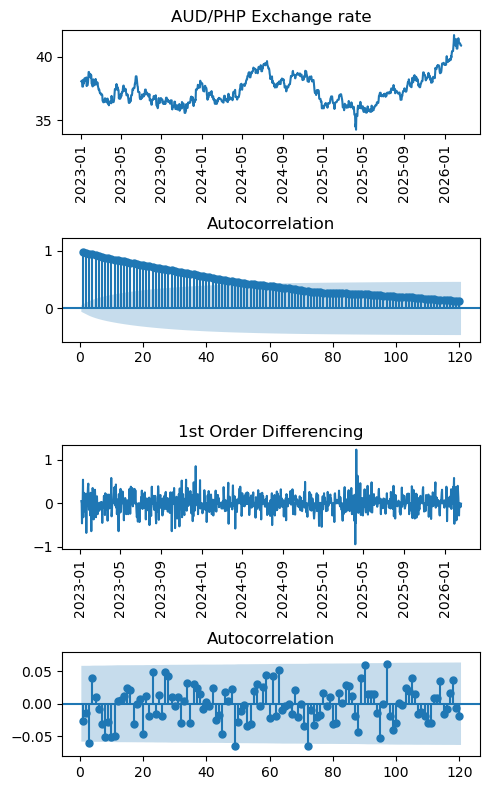

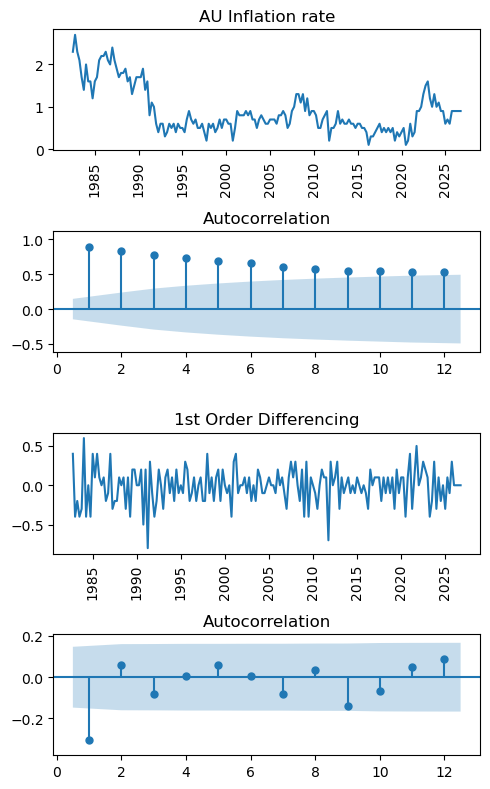

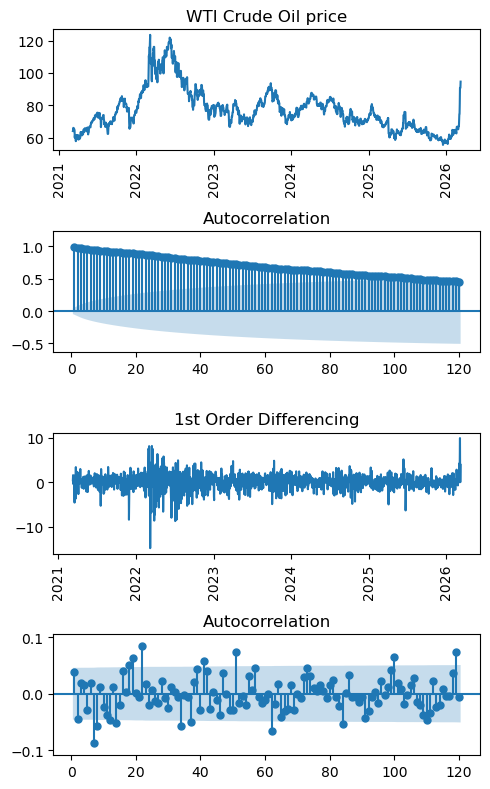

In [40]:
###plot 
def proc_acf_plots(df: pd.DataFrame, name: str) -> None:
    '''Compares the ACF plots between the 
    original series and the differenced series to assess stationarity.
    '''
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


    #get interval if daily, monthly, quarterly
    interval = pd.infer_freq(df['ds'])

    if interval == 'D':
        lags = 120
    elif interval == 'M':
        lags = 24
    elif interval == 'Q':
        lags = 8
    else:
        lags = 12

    fig, axes = plt.subplots(4, 1, figsize=(5, 8))
    axes[0].plot(df['ds'], df["y"]); axes[0].set_title(f'{name}')
    #rotate x-axis labels by 45 degrees
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90)
    #set line color to red
    
    plot_acf(df["y"], 
              zero=False,
              ax=axes[1],
              lags=lags,
              auto_ylims=True)

    axes[2].plot(df['ds'], df["y"].diff()); axes[2].set_title('1st Order Differencing')
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=90)

    plot_acf(df["y"].diff().dropna(),
             zero=False,
             ax=axes[3],
             lags=lags,
             auto_ylims=True)

    fig.tight_layout()
    plt.show()

    return

proc_acf_plots(df_aud, 'AUD/PHP Exchange rate')
proc_acf_plots(df_inf, 'AU Inflation rate')
proc_acf_plots(df_oil, 'WTI Crude Oil price')




In [41]:
HORIZON = 14
SEASONAL_LENGTH = 7
FREQ = 'D'
MODELS_USER = [ARIMA(order = (1,1,1),alias='ARIMA(1,1,1)')]

df_full = df_aud.query('ds.dt.year >= 2024')
df_train = df_aud.query('ds.dt.year >= 2024').iloc[:-HORIZON,:].reset_index(drop=True)
df_test =  df_aud.iloc[-HORIZON:,:].reset_index(drop=True)



sf = StatsForecast(models=[AutoARIMA(alias='AutoARIMA_AIC', ic='aicc')], freq=FREQ)

step_size=1
sf.cross_validation(h=1, df = df_full, step_size=step_size, test_size=HORIZON)

,unique_id,ds,cutoff,y,AutoARIMA_AIC
0,AUDPHP,2026-02-06,2026-02-05,40.66,41.02
1,AUDPHP,2026-02-07,2026-02-06,40.66,40.66
2,AUDPHP,2026-02-08,2026-02-07,40.66,40.66
3,AUDPHP,2026-02-09,2026-02-08,41.06,40.66
4,AUDPHP,2026-02-10,2026-02-09,41.35,41.06
5,AUDPHP,2026-02-11,2026-02-10,41.48,41.35
6,AUDPHP,2026-02-12,2026-02-11,41.37,41.48
7,AUDPHP,2026-02-13,2026-02-12,41.09,41.37
8,AUDPHP,2026-02-14,2026-02-13,41.09,41.09
9,AUDPHP,2026-02-15,2026-02-14,41.09,41.09



Best ARIMA specifications found by AutoARIMA:
AutoARIMA_AIC: ARIMA(0,1,0)                   
AutoARIMA_BIC: ARIMA(0,1,0)                   

Evaluating stationarity...
ADF Statistic: -10.604840
H0: The series is non-stationary
p-value: 0.000000

KPSS Statistic: 0.058039
H0: The series is stationary
p-value: 0.100000
***************************************************************************
Cross-validation results:


metric,mae,rmse,mape,mase,rmsse
RWD,0.51,0.62,1.30,2.07,1.95
"ARIMA(1,1,1)",0.51,0.62,1.31,2.09,1.96
Naive,0.51,0.62,1.31,2.09,1.97
"AutoARIMA_AIC_(0, 1, 0)",0.51,0.62,1.31,2.09,1.97
"AutoARIMA_BIC_(0, 1, 0)",0.51,0.62,1.31,2.09,1.97
SeasonalNaive,0.53,0.63,1.36,2.17,1.99


***************************************************************************
Results: Test set, 30 step ahead estimates:


metric,mae,rmse,mape,mase,rmsse
RWD,0.84,0.91,2.03,3.42,2.89
Naive,0.88,0.96,2.14,3.60,3.03
"AutoARIMA_AIC_(0, 1, 0)",0.88,0.96,2.14,3.60,3.03
"AutoARIMA_BIC_(0, 1, 0)",0.88,0.96,2.14,3.60,3.03
"ARIMA(1,1,1)",0.89,0.97,2.16,3.64,3.06
SeasonalNaive,1.13,1.20,2.76,4.64,3.81


***************************************************************************
Results: Test set, Iterative 1-step ahead nowcast results:


metric,mae,rmse,mape,mase,rmsse
Naive,0.18,0.25,0.44,0.74,0.79
"AutoARIMA_AIC_(0, 1, 0)",0.18,0.25,0.44,0.74,0.79
"AutoARIMA_BIC_(0, 1, 0)",0.18,0.25,0.44,0.74,0.79
RWD,0.18,0.25,0.44,0.74,0.79
"ARIMA(1,1,1)",0.18,0.25,0.45,0.75,0.80
SeasonalNaive,0.54,0.62,1.32,2.21,1.97


[Naive, SeasonalNaive, RWD, AutoARIMA_AIC_(0, 1, 0), AutoARIMA_BIC_(0, 1, 0), ARIMA(1,1,1)]


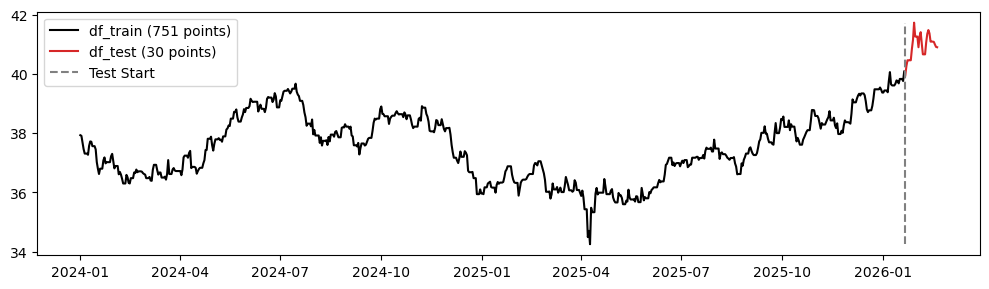

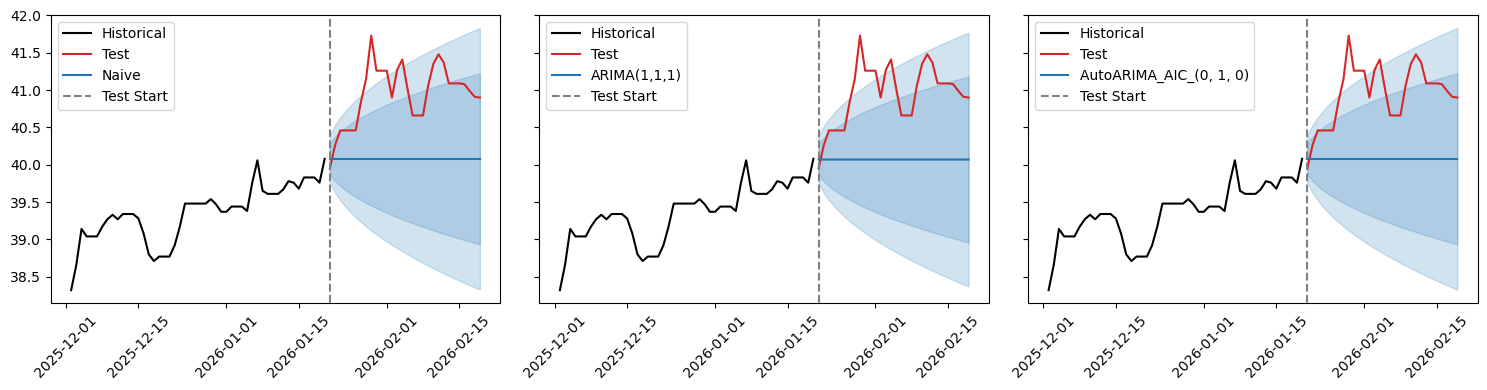

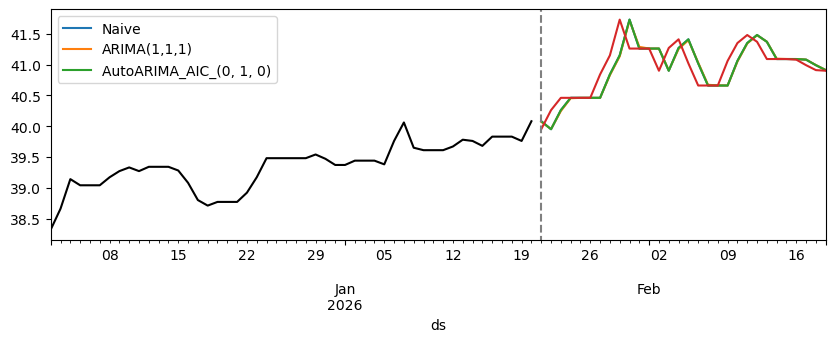

In [42]:
from statsforecast.models import AutoARIMA, ARIMA, Naive, SeasonalNaive, RandomWalkWithDrift
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape as _mape, mase, rmsse
from functools import partial
from statsforecast.arima import arima_string
import re

def evaluate_stationarity(series):
    '''Evaluates the stationarity of the series 
    using ADF and KPSS tests.
    '''
    from statsmodels.tsa.stattools import adfuller, kpss
    import warnings
    warnings.filterwarnings("ignore")

    print('\nEvaluating stationarity...')
    adf_result = adfuller(series.diff().dropna())
    print('ADF Statistic: %f' % adf_result[0])
    print("H0: The series is non-stationary")
    print('p-value: %f' % adf_result[1])

    kpss_result = kpss(series.diff().dropna(), regression='c',)
    print('\nKPSS Statistic: %f' % kpss_result[0])
    print("H0: The series is stationary")
    print('p-value: %f' % kpss_result[1])

    return

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

def proc_5stepEvaluation(df_train : pd.DataFrame,
                         df_test : pd.DataFrame,
                         MODELS_USER: list,
                         HORIZON : int = 14,
                         SEASONAL_LENGTH : int = 7,
                         FREQ: str = 'D',
                         ) -> pd.DataFrame:

    # We first run AutoARIMA to get the best order for the ARIMA model
    # then we use that order to fit a regular ARIMA model.

    df_full = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

    sf_auto = StatsForecast(models=[AutoARIMA(alias='AutoARIMA_AIC', ic='aicc'),
                                    AutoARIMA(alias='AutoARIMA_BIC', ic='bic'),
                                    ], freq=FREQ, n_jobs=-1)
    sf_auto.fit(df=df_train)

    print('\nBest ARIMA specifications found by AutoARIMA:')
    BEST_ARIMA_MODELS = []
    for model in sf_auto.models:
        spec = arima_string(sf_auto.fitted_[0, 0].model_)
        m = re.search(r'ARIMA\((\d+),(\d+),(\d+)\)', spec)
        order = tuple(map(int, m.groups())) if m else None
        print(f'{model.alias}: {spec}')
        BEST_ARIMA_MODELS.append(ARIMA(order=order,
                                    alias=f'{model.alias}_{order}'))

    ####
    models = [
        Naive(),
        SeasonalNaive(season_length = SEASONAL_LENGTH),
        RandomWalkWithDrift(),
    ]
    models += BEST_ARIMA_MODELS
    models += MODELS_USER

    #### PLOT TRAIN-TEST SPLIT
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(df_train['ds'], df_train['y'], label=f'df_train ({len(df_train)} points)', color='k')
    ax.plot(df_test['ds'], df_test['y'], label=f'df_test ({len(df_test)} points)', color='tab:red')
    ax.vlines(x=df_test['ds'].min(),
            ymin = min(df_train['y'].min(), df_test['y'].min()),
            ymax = max(df_train['y'].max(), df_test['y'].max()),
            color='grey',
            linestyle='--', label='Test Start')
    fig.tight_layout()
    plt.legend()
    fig.show()

    #### Evaluate stationarity of the series
    evaluate_stationarity(df_train['y'].diff(1).dropna())

    #### Fit models and evaluate forecasts
    sf = StatsForecast(models=models, freq=FREQ, n_jobs=-1)

    if FREQ == 'D':
        step_size = 7
        n_windows = 10
    if FREQ == 'Q':
        step_size = 1
        n_windows = 4


    df_cv = sf.cross_validation(h=HORIZON, df = df_train, n_windows= n_windows, step_size=step_size)
    df_cv = df_cv.drop(['cutoff'], axis=1)
    dfcv_eval = evaluate(df_cv, metrics=[mae, rmse, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_train)
    print('*'*75)
    print('Cross-validation results:')
    res = dfcv_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')
    #convert all to float and round to 2 decimals
    display(res.astype(float).round(2))

    #### Evaluate test set
    sf.fit(df_train)
    dff = sf.predict(h=HORIZON, level=[80,95])
    dff['y'] = df_test['y'].values
    dff_eval = evaluate(dff, metrics=[mae, rmse, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_train)
    print('*'*75)
    print(f'Results: Test set, {HORIZON} step ahead estimates:')
    res = dff_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae').round(2)
    display(res.astype(float).round(2))
    
    #### Evaluate iterative nowcast
    df_itr = sf.cross_validation(h=1, df = df_full, step_size=1, test_size=HORIZON)
    dfitr_eval = evaluate(df_itr.drop(['cutoff'],axis=1), 
                          metrics=[mae, rmse, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_train)
    print('*'*75)
    print('Results: Test set, Iterative 1-step ahead nowcast results:')
    res = dfitr_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae').round(2)
    display(res.astype(float).round(2))

    print(models)
    
    return dfcv_eval, dff, df_itr

def proc_plot(select_models,
              df_train,
              dff,
              df_itr):
        
    fig, ax = plt.subplots(1, len(select_models), figsize=(15, 4), sharey=True)
    for i, model_name in enumerate(select_models):
        ax[i].plot(df_train['ds'].iloc[-50:], df_train['y'].iloc[-50:], label='Historical', color='k')
        ax[i].plot(df_test['ds'], df_test['y'], label='Test', color='tab:red')
        ax[i].plot(dff['ds'], dff[model_name], label=model_name, color='tab:blue')
        ax[i].fill_between(dff["ds"], dff[f'{model_name}-lo-95'], dff[f'{model_name}-hi-95'], color='tab:blue', alpha = 0.2)
        ax[i].fill_between(dff["ds"], dff[f'{model_name}-lo-80'], dff[f'{model_name}-hi-80'], color='tab:blue', alpha = 0.2)
        ax[i].axvline(x=dff['ds'].min(),
                ymin = -1000,
                ymax = 1000,
                color='grey',
                linestyle='--', label='Test Start')
        ax[i].legend(loc='upper left')

        #rotate x-axis labels by 45 degrees
        plt.setp(ax[i].xaxis.get_majorticklabels(), rotation=45)
    fig.tight_layout()


    tmp = df_itr.copy()
    tmp.set_index('ds', inplace=True)
    tmp = tmp.loc[:,['y']+select_models]
    fig, ax = plt.subplots(figsize=(10, 3))
    tmp[select_models].plot(ax = ax)
    tmp['y'].plot(ax=ax,color='tab:red')
    ax.axvline(x=tmp.index.min(),
            ymin = -1000,
            ymax = 1000,
            color='grey',
            linestyle='--', label='Test Start')
    df_train.set_index('ds').iloc[-50:]['y'].plot(label='Historical', color='k', ax=ax)

    return
#if daily, use last 30 days as test set
HORIZON = 30
SEASONAL_LENGTH = 7
FREQ = 'D'
MODELS_USER = [ARIMA(order = (1,1,1),alias='ARIMA(1,1,1)')]

df_train = df_aud.query('ds.dt.year >= 2024').iloc[:-HORIZON,:].reset_index(drop=True)
df_test =  df_aud.iloc[-HORIZON:,:].reset_index(drop=True)

dfcv_eval, dff, df_itr = proc_5stepEvaluation(df_train, 
                                      df_test, 
                                      MODELS_USER, HORIZON, SEASONAL_LENGTH, FREQ='D')
#### plot forecast
select_models = ['Naive','ARIMA(1,1,1)','AutoARIMA_AIC_(0, 1, 0)']
proc_plot(select_models, df_train, dff, df_itr)



Best ARIMA specifications found by AutoARIMA:
AutoARIMA_AIC: ARIMA(0,1,1)                   
AutoARIMA_BIC: ARIMA(0,1,1)                   

Evaluating stationarity...
ADF Statistic: -7.388546
H0: The series is non-stationary
p-value: 0.000000

KPSS Statistic: 0.346790
H0: The series is stationary
p-value: 0.100000
***************************************************************************
Cross-validation results:


metric,mae,rmse,mape,mase,rmsse
SeasonalNaive,0.60,0.73,71.79,2.39,2.11
"AutoARIMA_AIC_(0, 1, 1)",0.62,0.75,73.30,2.46,2.17
"AutoARIMA_BIC_(0, 1, 1)",0.62,0.75,73.30,2.46,2.17
"ARIMA(1,1,0)",0.63,0.76,75.68,2.51,2.21
Naive,0.65,0.77,79.67,2.56,2.24
RWD,0.72,0.86,85.32,2.85,2.50


***************************************************************************
Results: Test set, 12 step ahead estimates:


metric,mae,rmse,mape,mase,rmsse
"ARIMA(1,1,0)",0.37,0.40,48.25,1.48,1.16
"AutoARIMA_AIC_(0, 1, 1)",0.38,0.40,48.81,1.50,1.18
"AutoARIMA_BIC_(0, 1, 1)",0.38,0.40,48.81,1.50,1.18
RWD,0.40,0.43,51.74,1.59,1.24
SeasonalNaive,0.42,0.49,53.38,1.65,1.42
Naive,0.44,0.46,56.53,1.75,1.35


***************************************************************************
Results: Test set, Iterative 1-step ahead nowcast results:


metric,mae,rmse,mape,mase,rmsse
"ARIMA(1,1,0)",0.10,0.15,12.59,0.39,0.42
"AutoARIMA_AIC_(0, 1, 1)",0.11,0.16,13.94,0.44,0.45
"AutoARIMA_BIC_(0, 1, 1)",0.11,0.16,13.94,0.44,0.45
Naive,0.12,0.17,14.63,0.46,0.49
RWD,0.12,0.17,14.92,0.47,0.49
SeasonalNaive,0.26,0.31,32.28,1.02,0.91


[Naive, SeasonalNaive, RWD, AutoARIMA_AIC_(0, 1, 1), AutoARIMA_BIC_(0, 1, 1), ARIMA(1,1,0)]


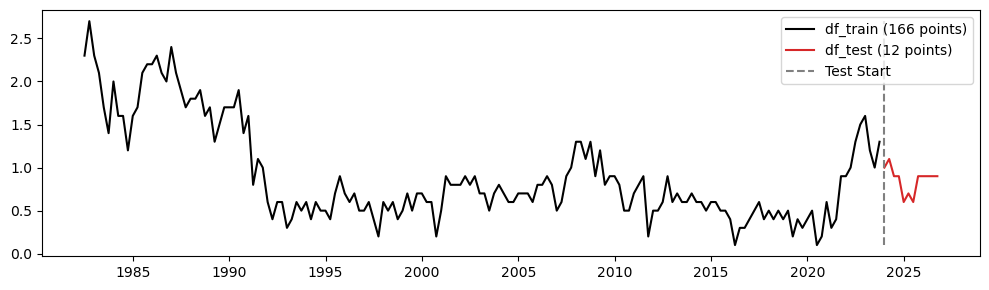

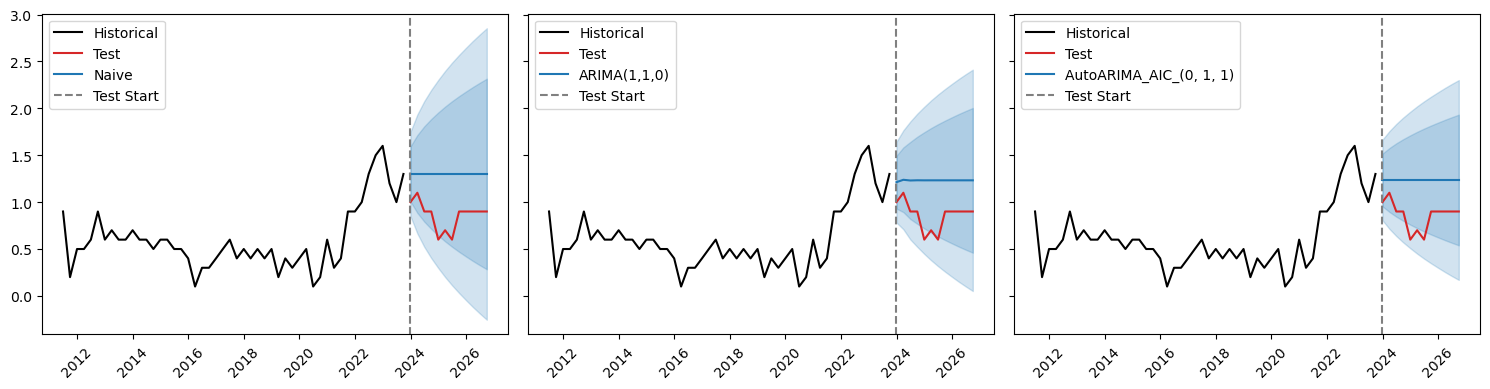

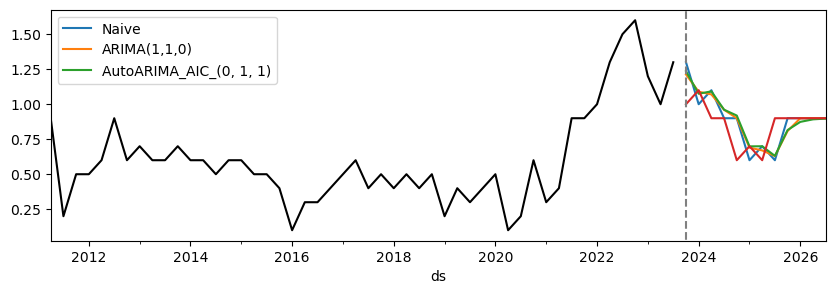

In [43]:
#if daily, use last 30 days as test set
HORIZON = 12
SEASONAL_LENGTH = 4
FREQ = 'Q'
df_train = df_inf.iloc[:-HORIZON,:].reset_index(drop=True)
df_test =  df_inf.iloc[-HORIZON:,:].reset_index(drop=True)
MODELS_USER = [ARIMA(order = (1,1,0),alias='ARIMA(1,1,0)')]

dfcv_eval, dff, df_itr = proc_5stepEvaluation(df_train, df_test, MODELS_USER, HORIZON, SEASONAL_LENGTH, FREQ=FREQ)
#### plot forecast
select_models = ['Naive','ARIMA(1,1,0)','AutoARIMA_AIC_(0, 1, 1)']
proc_plot(select_models, df_train, dff, df_itr)


Best ARIMA specifications found by AutoARIMA:
AutoARIMA_AIC: ARIMA(0,1,0)                   
AutoARIMA_BIC: ARIMA(0,1,0)                   

Evaluating stationarity...
ADF Statistic: -16.931186
H0: The series is non-stationary
p-value: 0.000000

KPSS Statistic: 0.034021
H0: The series is stationary
p-value: 0.100000
***************************************************************************
Cross-validation results:


metric,mae,rmse,mape,mase,rmsse
Naive,1.73,2.28,2.91,0.78,0.73
"AutoARIMA_AIC_(0, 1, 0)",1.73,2.28,2.91,0.78,0.73
"AutoARIMA_BIC_(0, 1, 0)",1.73,2.28,2.91,0.78,0.73
RWD,1.73,2.30,2.92,0.78,0.74
"ARIMA(7,1,5)",1.74,2.29,2.93,0.79,0.74
SeasonalNaive,2.03,2.59,3.41,0.92,0.83


***************************************************************************
Results: Test set, 30 step ahead estimates:


metric,mae,rmse,mape,mase,rmsse
"ARIMA(7,1,5)",6.42,11.25,7.84,2.90,3.62
Naive,6.50,11.26,7.95,2.94,3.63
"AutoARIMA_AIC_(0, 1, 0)",6.50,11.26,7.95,2.94,3.63
"AutoARIMA_BIC_(0, 1, 0)",6.50,11.26,7.95,2.94,3.63
RWD,6.50,11.27,7.95,2.94,3.63
SeasonalNaive,6.83,11.57,8.42,3.08,3.73


***************************************************************************
Results: Test set, Iterative 1-step ahead nowcast results:


metric,mae,rmse,mape,mase,rmsse
RWD,1.31,2.57,1.70,0.59,0.83
Naive,1.31,2.58,1.70,0.59,0.83
"AutoARIMA_AIC_(0, 1, 0)",1.31,2.58,1.70,0.59,0.83
"AutoARIMA_BIC_(0, 1, 0)",1.31,2.58,1.70,0.59,0.83
"ARIMA(7,1,5)",1.42,2.69,1.84,0.64,0.87
SeasonalNaive,5.61,9.63,6.91,2.54,3.10


[Naive, SeasonalNaive, RWD, AutoARIMA_AIC_(0, 1, 0), AutoARIMA_BIC_(0, 1, 0), ARIMA(7,1,5)]


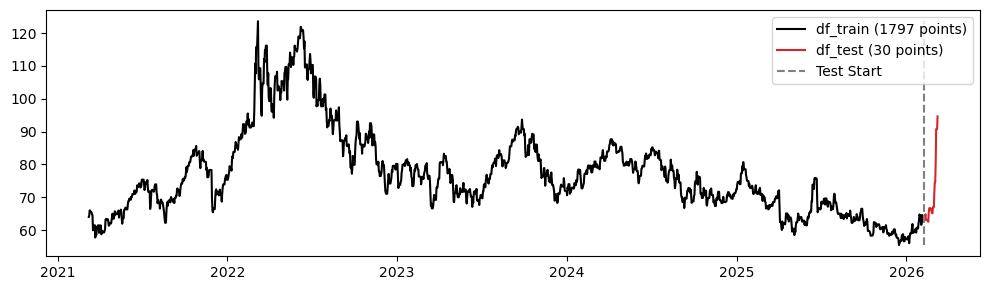

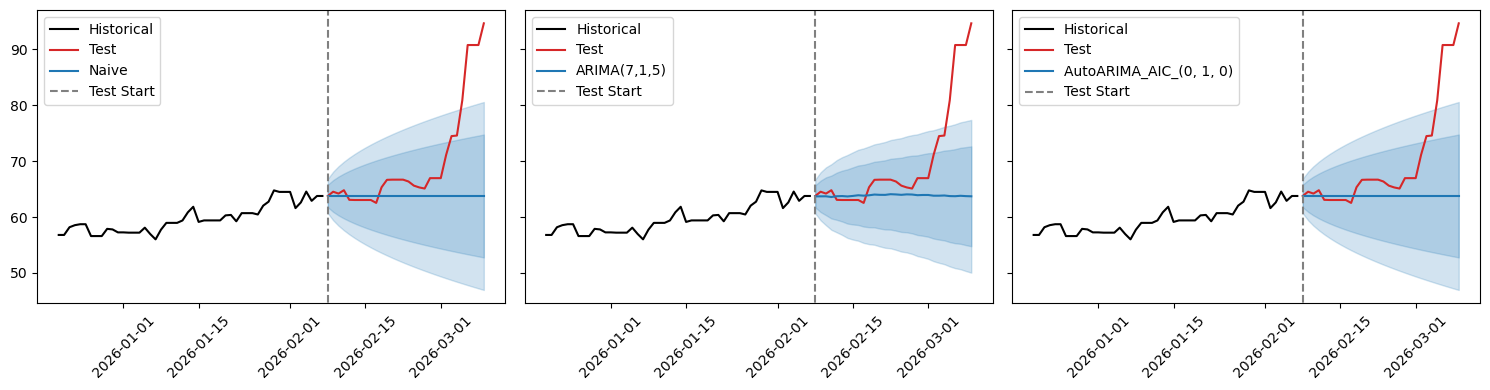

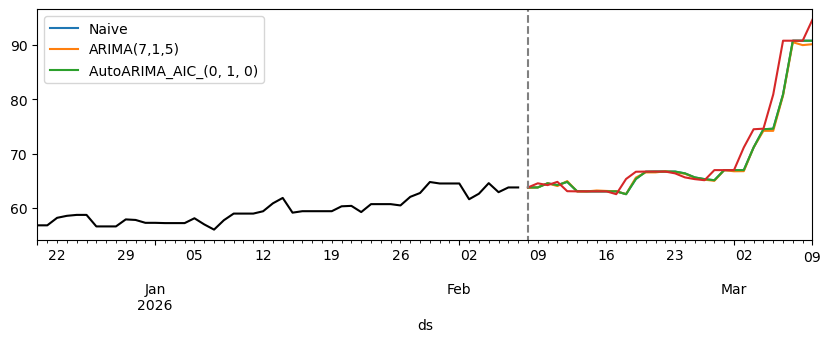

In [44]:
#if daily, use last 30 days as test set
HORIZON = 30
SEASONAL_LENGTH = 7
FREQ = 'D'
df_train = df_oil.iloc[:-HORIZON,:].reset_index(drop=True)
df_test =  df_oil.iloc[-HORIZON:,:].reset_index(drop=True)
MODELS_USER = [ARIMA(order = (7,1,5), 
                     alias='ARIMA(7,1,5)')]

dfcv_eval, dff, df_itr = proc_5stepEvaluation(df_train, df_test, MODELS_USER, HORIZON, SEASONAL_LENGTH, FREQ=FREQ)
#### plot forecast
select_models = ['Naive','ARIMA(7,1,5)','AutoARIMA_AIC_(0, 1, 0)']
proc_plot(select_models, df_train, dff, df_itr)

In [23]:
#Consider iteratively refitting the model with shorter horizons

evaluate_stationarity(df_oil['y'].diff().dropna())


Evaluating stationarity...
ADF Statistic: -16.425345
H0: The series is non-stationary
p-value: 0.000000

KPSS Statistic: 0.092575
H0: The series is stationary
p-value: 0.100000
